### PhaseGuard - Electrical Power Line Fault Classifier

In [1]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [2]:
df= pd.read_csv("classData.csv")

In [5]:
df.head()
df.describe() # Ia, Ib, Ic => -900 to 900 & Va, Vb, Vc => -0.6 to 0.6 (normalized values)


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
count,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000
mean,0.432006,0.411271,0.555527,0.571429,13.721194,-44.845268,34.392394,-0.007667,0.001152,0.006515
std,0.495387,0.492095,0.496939,0.494903,464.741671,439.269195,371.107412,0.289150,0.313437,0.307897
min,0.000000,0.000000,0.000000,0.000000,-883.542316,-900.526951,-883.357762,-0.620748,-0.608016,-0.612709
25%,0.000000,0.000000,0.000000,0.000000,-119.802518,-271.845947,-61.034219,-0.130287,-0.159507,-0.215977
50%,0.000000,0.000000,1.000000,1.000000,2.042805,5.513317,-4.326711,-0.005290,0.001620,0.009281
75%,1.000000,1.000000,1.000000,1.000000,227.246377,91.194282,49.115141,0.111627,0.153507,0.239973
max,1.000000,1.000000,1.000000,1.000000,885.738571,889.868884,901.274261,0.595342,0.627875,0.600179


In [ ]:
# Data Preprocessing 
# Checing null values, datatypes and dulicates
df.isnull().sum()
df.info()
df.duplicated().sum()
df.shape    #(7861, 10)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       7861 non-null   int64  
 1   C       7861 non-null   int64  
 2   B       7861 non-null   int64  
 3   A       7861 non-null   int64  
 4   Ia      7861 non-null   float64
 5   Ib      7861 non-null   float64
 6   Ic      7861 non-null   float64
 7   Va      7861 non-null   float64
 8   Vb      7861 non-null   float64
 9   Vc      7861 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 614.3 KB


(7861, 10)

In [ ]:
# merge 4 output columns to one with fault logic
def get_fault_type(rowData):
    a, b, c, g =rowData["A"], rowData["B"], rowData["C"], rowData["G"]
    if a==0 and b==0 and c==0 and g==0:
        return "No Fault"
    elif a==1 and b==0 and c==0 and g==1:
        return "AG"
    elif a==1 and b==1 and c==0 and g==1:
        return "ABG"
    elif a==0 and b==1 and c==1 and g==0:
        return "BC" 
    elif a==1 and b==1 and c==1 and g==0:
        return "ABC"
    elif a==1 and b==1 and c==1 and g==1:
        return "ABCG"
    else:
         return "Unknown Fault"
df["Fault_Type"] = df.apply (get_fault_type, axis=1)



In [ ]:

df["Fault_Type"].value_counts()
df.sample(2)




,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,Fault_Type
5978,0,0,0,0,33.526635,-25.907749,-11.054571,0.510620,0.020557,-0.531177,No Fault
7493,0,0,0,0,-43.584357,3.635221,36.978656,0.403979,-0.570911,0.166932,No Fault


In [ ]:
X=df[["Ia", "Ib", "Ic", "Va", "Vb", "Vc"]]
y=df["Fault_Type"]

# Split the dataset
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# define the model 
model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
y_pred=model.predict(X_test)

# getting probabilities values 
y_proba = model.predict_proba(X_test)

In [ ]:
# Printing Probability values 
print(model.classes_)
print(y_proba[:12])

['ABC' 'ABCG' 'ABG' 'AG' 'BC' 'No Fault']
[[0.   0.   0.   0.   0.   1.  ]
 [0.89 0.11 0.   0.   0.   0.  ]
 [0.   0.   0.99 0.01 0.   0.  ]
 [0.   0.   1.   0.   0.   0.  ]
 [0.8  0.2  0.   0.   0.   0.  ]
 [0.   0.   0.   1.   0.   0.  ]
 [0.   0.   0.   0.   0.   1.  ]
 [0.   0.   0.   0.   0.01 0.99]
 [0.63 0.37 0.   0.   0.   0.  ]
 [0.19 0.81 0.   0.   0.   0.  ]
 [0.33 0.67 0.   0.   0.   0.  ]
 [0.53 0.47 0.   0.   0.   0.  ]]


In [ ]:
# check for overfitting 

y_train_pred=model.predict(X_train)
train_acc= accuracy_score(y_train, y_train_pred)
test_acc= accuracy_score(y_test, y_pred)

print(f" Training Acuuray: {train_acc}")
print(f" Testing Acuuray: {test_acc}")

class_report=classification_report(y_test, y_pred)
print(f"Classification Report: {class_report}")

# Although Training accuracy is 100% but this is not a classical example of overfitting.
# Behavious of ABC and ABCG faults are forcing this behaviour which has electrical concepts related reason. But certainly not the model memorising data here. 



 Training Acuuray: 1.0
 Testing Acuuray: 0.863318499682136
Classification Report:               precision    recall  f1-score   support

         ABC       0.52      0.55      0.53       219
        ABCG       0.54      0.51      0.52       227
         ABG       1.00      0.98      0.99       227
          AG       0.98      1.00      0.99       226
          BC       1.00      1.00      1.00       201
    No Fault       1.00      1.00      1.00       473

    accuracy                           0.86      1573
   macro avg       0.84      0.84      0.84      1573
weighted avg       0.86      0.86      0.86      1573



In [ ]:
# to confirm the behaviour of ABC & ABCG - check cinfusion metrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
print(pd.DataFrame(cm, index=model.classes_, columns=model.classes_))

# bahaviour of ABC and ABCG in confusion matrix is confirming the above finding. 


          ABC  ABCG  ABG   AG   BC  No Fault
ABC       121    98    0    0    0         0
ABCG      112   115    0    0    0         0
ABG         0     0  223    4    0         0
AG          1     0    0  225    0         0
BC          0     0    0    0  201         0
No Fault    0     0    0    0    0       473


In [ ]:
# check correlation of all features 
corr = df[['Ia','Ib','Ic','Va','Vb','Vc']].corr()
corr

,Ia,Ib,Ic,Va,Vb,Vc
Ia,1.000000,-0.374241,-0.276457,0.035682,-0.274612,0.246043
Ib,-0.374241,1.000000,-0.528291,0.029118,0.032101,-0.060023
Ic,-0.276457,-0.528291,1.000000,-0.069137,-0.056967,0.122919
Va,0.035682,0.029118,-0.069137,1.000000,-0.480247,-0.450225
Vb,-0.274612,0.032101,-0.056967,-0.480247,1.000000,-0.566986
Vc,0.246043,-0.060023,0.122919,-0.450225,-0.566986,1.000000


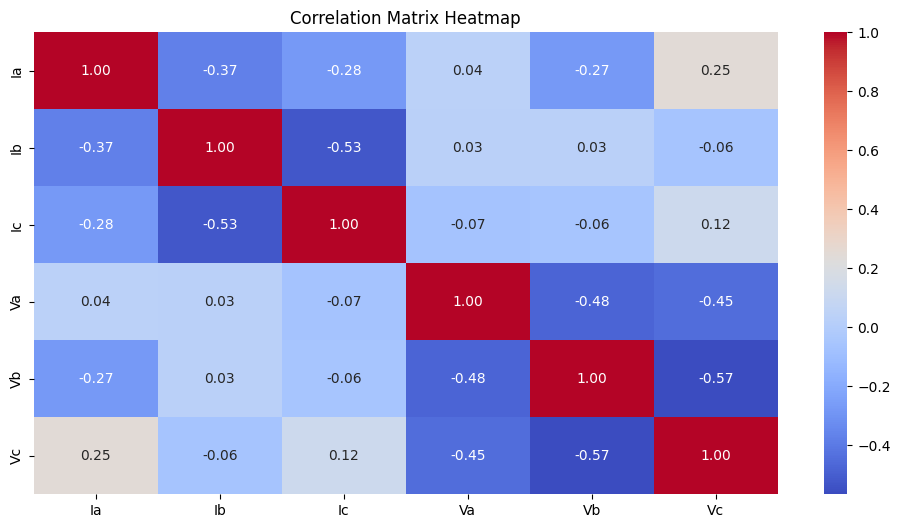

In [ ]:
# heatmap of input features
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

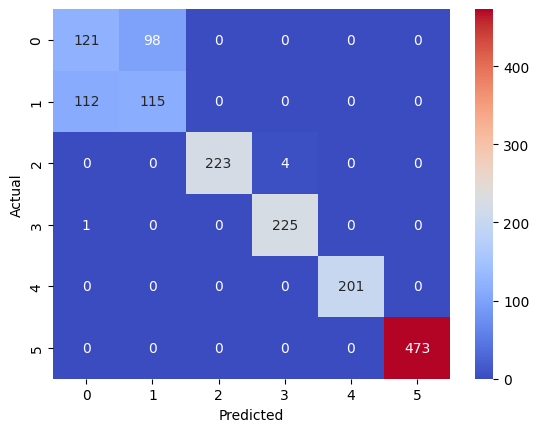

In [ ]:
# Heatmap of confusion matrix to visually see the relationship of all 6  faults
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

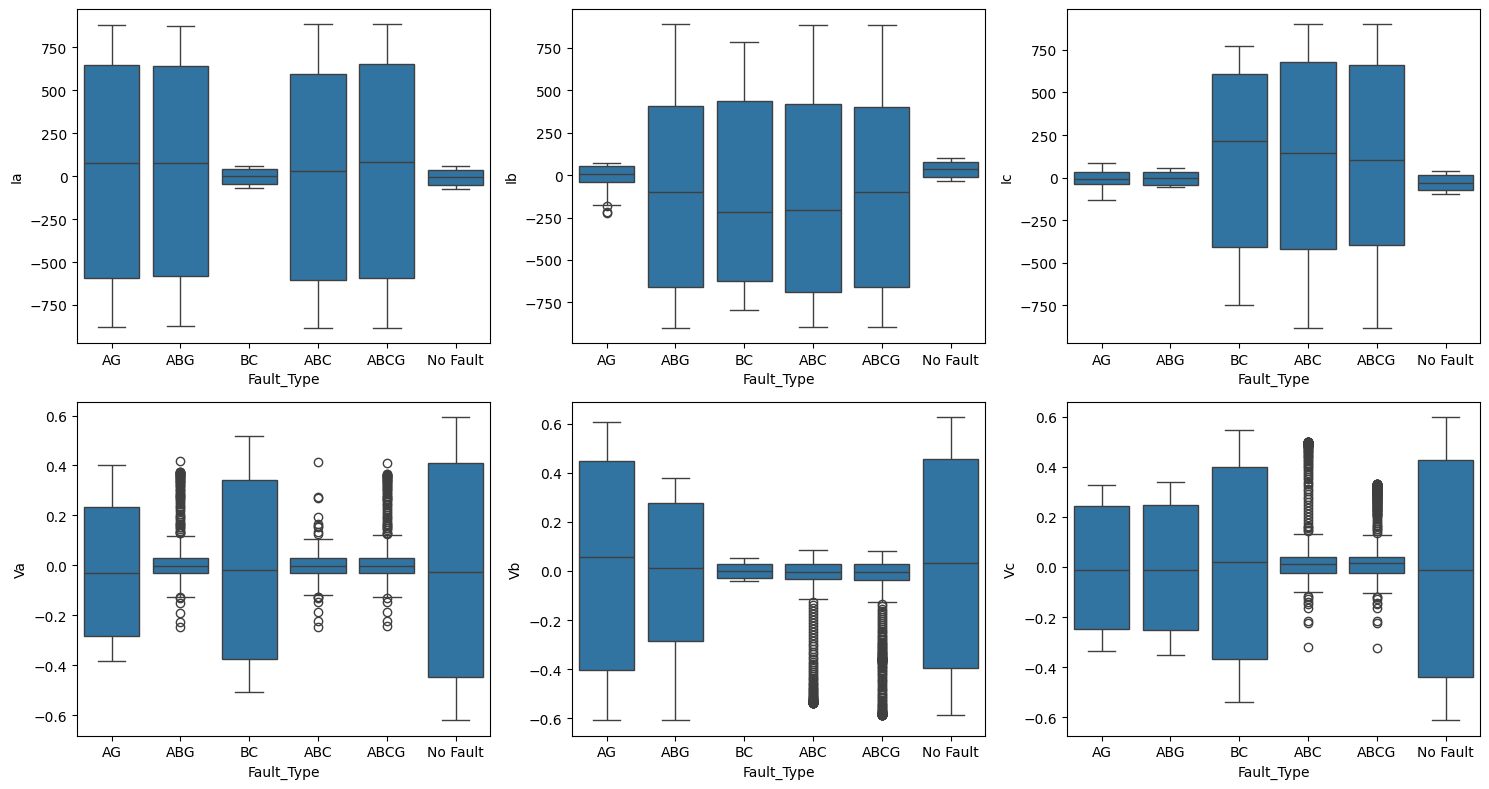

In [ ]:
# Box plot to check behaviour of ABC and ABCG faults across all input features

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['Ia','Ib','Ic','Va','Vb','Vc']
for i, feat in enumerate(features):
    sns.boxplot(data=df, x='Fault_Type', y=feat, ax=axes[i//3, i%3])
plt.tight_layout()
plt.show()

In [ ]:

# saving the model 
import joblib
joblib.dump(model, 'phaseguard_model.pkl')
print("Model saved successfully")


Model saved successfully


In [ ]:
# quick check to reload the model
loaded_model = joblib.load('phaseguard_model.pkl')
print(loaded_model.predict(X_test[:5]))

['No Fault' 'ABC' 'ABG' 'ABG' 'ABC']


: 